# Clase 1: Análisis de Algoritmos y SGD

En esta clase implementamos y comparamos:
- Complejidad computacional de operaciones comunes
- Batch Gradient Descent (GD completo)
- Stochastic Gradient Descent con minibatches (SGD)

Todo desde cero, sin sklearn, para entender qué pasa adentro.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

## 1. Complejidad computacional

La complejidad mide cuántas operaciones realiza un algoritmo en función del tamaño de entrada `n`.
No medimos segundos (dependen del hardware), medimos **operaciones elementales**.

El tiempo asintótico `T(n)` nos dice cómo crece el costo cuando `n` es grande.

In [10]:
# Crea una función que sume los elementos de una lista
def suma_lista(lista):
    total = 0
    for i in lista:
        total += i
    return total

#Crea una función que cuente cuántos parejas de elementos iguales hay en una lista
# ejemplo: [1, 2, 3, 2, 1] tiene 2 parejas de elementos iguales (1 y 2)
def pares_iguales(lista):
    parejas = 0
    for i in lista:
        for j in lista: 
            if i == j:
                parejas += 1
    return parejas

def pares_iguales_optimizado(lista):
    parejas = {}
    for i in lista:
        if i in parejas:
            parejas[i] += 1
        else:
            parejas[i] = 0

    total_parejas = sum(parejas.values())
    return total_parejas

#crea una función que devuelva el primer elemento de una lista
def primer_elemento(lista):
    return lista[0]

In [11]:
# Midamos empíricamente cómo crece el tiempo con n
sizes = [100, 500, 1000, 3000, 4000, 7000 ,10000]

tiempos_on = []
tiempos_on2 = []
tiempos_on3 = []

for n in sizes:
    lista = list(range(n))

    t0 = time.time()
    pares_iguales_optimizado(lista)
    tiempos_on.append(time.time() - t0)

    t0 = time.time()
    pares_iguales(lista)
    tiempos_on2.append(time.time() - t0)

    t0 = time.time()
    primer_elemento(lista)
    tiempos_on3.append(time.time() - t0)

print(f"{'n':>6}  {'O(n) ms':>10}  {'O(n²) ms':>12}  {'O(1) ms':>12}")
print("-" * 45)
for n, t1, t2, t3 in zip(sizes, tiempos_on, tiempos_on2, tiempos_on3):
    print(f"{n:>6}  {t1*1000:>10.2f}  {t2*1000:>12.2f}  {t3*1000:>12.2f}")

     n     O(n) ms      O(n²) ms       O(1) ms
---------------------------------------------
   100        0.06          0.67          0.01
   500        0.16         36.00          0.01
  1000        0.54        108.22          0.01
  3000        2.98       1067.50          0.01
  4000        7.99       2072.44          0.00
  7000        1.13       5995.78          0.01
 10000        3.53      10063.45          0.01


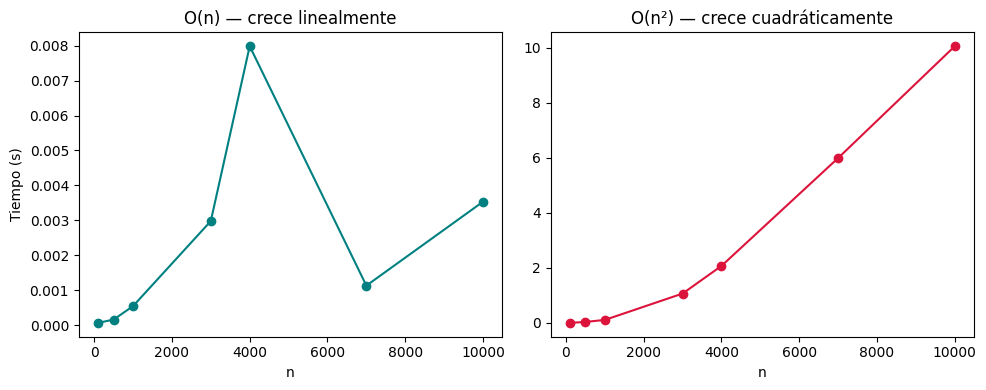

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(sizes, tiempos_on, 'o-', color='teal')
axes[0].set_title('O(n) — crece linealmente')
axes[0].set_xlabel('n'); axes[0].set_ylabel('Tiempo (s)')

axes[1].plot(sizes, tiempos_on2, 'o-', color='crimson')
axes[1].set_title('O(n²) — crece cuadráticamente')
axes[1].set_xlabel('n')

plt.tight_layout()
plt.show()

## 2. Dataset sintético

Generamos datos para un problema de regresión lineal.
La relación verdadera es: `y = 3*x1 - 2*x2 + ruido`.

In [14]:
np.random.seed(42)
n_samples = 10000
n_features = 50

X = np.random.randn(n_samples, n_features)
true_w = np.zeros(n_features)
true_w[0] = 3.0
true_w[1] = -2.0

y = X @ true_w + np.random.randn(n_samples) * 0.5

# Agregar columna de unos para el bias (w0)
X_b = np.column_stack([np.ones(n_samples), X])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10000, 50)
y shape: (10000,)


## 3. Batch Gradient Descent

En cada iteración usa **todos los datos** para calcular el gradiente.

- Gradiente: `∇J = (2/n) · Xᵀ · (Xw − y)`
- Actualización: `w ← w − step_size · ∇L`

Complejidad por iteración: **O(n · p)** — procesa todo el dataset.

In [19]:
class BatchGD:
    def __init__(self, learning_rate = 0.01, epochs = 100):
        self.learning_rate = learning_rate
        self.epochs = epochs
    
    def fit(self, X, y):
        n = len(y)
        w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            y_pred = X @ w
            error = y_pred - y
            loss = np.mean(error ** 2)
            losses.append(loss)
            grad = (2/n) * X.T @ error
            w -= self.learning_rate * grad
            
        self.w = w
        self.losses = losses
        
    
    def predict(self, X):
        return X @ self.w

## 4. Stochastic Gradient Descent (minibatch)

En cada iteración usa solo un **minibatch** de `batch_size` ejemplos.

- Gradiente aproximado pero mucho más rápido de calcular
- Una **época** = el modelo ha visto todos los datos una vez
- Complejidad por época: **O(n · p)** igual, pero muchas actualizaciones intermedias

In [34]:
class StochasticGD:
    def __init__(self, learning_rate = 0.01, epochs = 100 , batch_size = 100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self, X, y):
        n = len(y) #1000
        w = np.zeros(X.shape[1])
        losses = []
        for epoch in range(self.epochs):
            # Mezclar los datos
            indices_x = np.arange(n)
            np.random.shuffle(indices_x)
            X_ran = X[indices_x]
            y_ran = y[indices_x]

            # Entrenar en mini-batches
            for i in range(0, n, self.batch_size): #[0,100,200,300]
                X_batch = X_ran[i:i+self.batch_size]
                y_batch = y_ran[i:i+self.batch_size]

                y_pred = X_batch @ w
                error = y_pred - y_batch
                grad = (2/self.batch_size) * X_batch.T @ error
                w -= self.learning_rate * grad

            epoch_pred = X @ w
            losses.append(np.mean((epoch_pred - y)**2))
            
        self.w = w
        self.losses = losses

    def predict(self, X):
        return X @ self.w

## 5. Comparación empírica

In [37]:
# Entrenamos ambos y medimos tiempo
batch_model = BatchGD(learning_rate = 0.01, epochs = 200)
t0 = time.time()
batch_model.fit(X_b, y)
t_batch = time.time() - t0

sgd_model = StochasticGD(learning_rate = 0.01, epochs = 50, batch_size=200)
t0 = time.time()
sgd_model.fit(X_b, y)
t_sgd = time.time() - t0

print(f"Batch GD — tiempo: {t_batch:.3f}s | MSE final: {batch_model.losses[-1]:.4f}")
print(f"SGD      — tiempo: {t_sgd:.3f}s  | MSE final: {sgd_model.losses[-1]:.4f}")

Batch GD — tiempo: 4.469s | MSE final: 0.2557
SGD      — tiempo: 1.670s  | MSE final: 0.2516


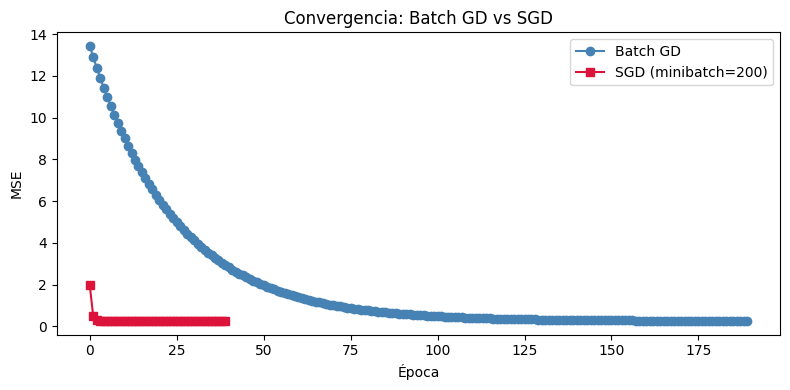

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(batch_model.losses[:-10], 'o-', label='Batch GD', color='steelblue')
plt.plot(sgd_model.losses[:-10], 's-', label='SGD (minibatch=200)', color='crimson')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Convergencia: Batch GD vs SGD')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Efecto del batch_size

¿Cómo cambia la convergencia según el tamaño del batch?
- Batch pequeño: más ruido, más actualizaciones, puede escapar mínimos locales
- Batch grande: más estable pero más costo por iteración

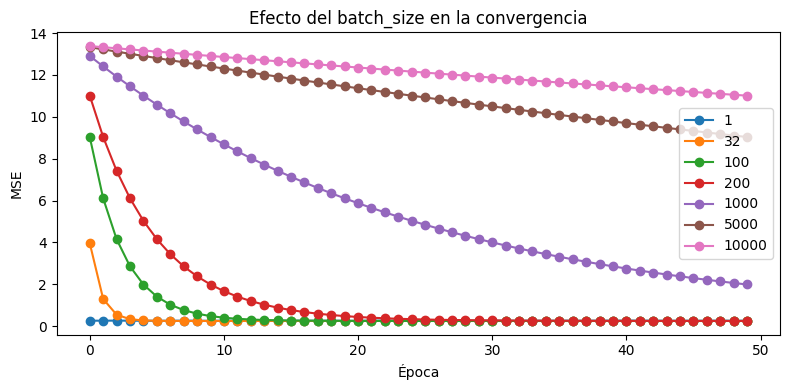

In [40]:
batch_sizes = [1, 32, 100, 200, 1000, 5000, len(X_b)]    
results = {}

for bs in batch_sizes:
    sgd_model = StochasticGD(learning_rate=0.001, epochs=50, batch_size=bs)
    sgd_model.fit(X_b, y)
    results[bs] = sgd_model.losses

plt.figure(figsize=(8, 4))
for label, losses in results.items():
    plt.plot(losses, 'o-', label=label)
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Efecto del batch_size en la convergencia')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

- **O(n)** es siempre preferible a **O(n²)** en datasets grandes
- **Batch GD** calcula gradientes exactos pero escala mal con `n`
- **SGD con minibatches** es la solución estándar en ML: rápido, eficiente en memoria
- Un `batch_size` de 100-200 suele dar buen equilibrio velocidad/estabilidad
- Con suficientes épocas, SGD converge a resultados comparables a Batch GD